# Geophysical Inversion
## Homework 2
## Magnús Pálsson


### Problem 1

What is the mean and variance of the uniform distribution $p(d)=1$ on the interval $[0,1]$

#### Solution

The mean is $\langle x\rangle=E(x)=\int_{-\infty}^{\infty}xp(x)dx =\int_0^1xdx=0.5$ (It's a triangle that is half a unit square, no need to do calculus)

The variance is $\sigma^2 = \int_{-\infty}^{\infty}(x -  \langle x \rangle)^2p(x)dx = \int_0^1(x-0.5)^2dx = \int_{-0.5}^{0.5}u^2du = \frac{0.5^3 - (-0.5)^3}{3} = \frac{1}{12}$

with $u = x-0.5$

### Problem 3

Write a program to create a vector $\mathbf{d}$ of $N=1000$ realisations of a Gaussian-distributed random variable with mean $\langle x \rangle = 4$ and variance $\sigma_x^2 = 2^2$

Count up the number of realisations of the variable where $x_i > ( \langle x \rangle + 2\sigma_x)$ Is it about what you expected?

#### Solution

In [2]:
import numpy as np

def calculate_value(mean, stdev, size):
    d = np.random.normal(loc = mean, scale = stdev, size = size)

    ref = mean + 2*stdev
    mask = d > ref #Array of True/False for the boolean check
    return np.sum(mask) #True/False are just 1/0 under the hood so we can sum up the array to get a count

mean = 4
stdev = 2
size = 1000

calculate_value(mean, stdev, size)



np.int64(18)

This is about what we expect. For a Gaussian-distributed variable about $95\%$ of realisations should land within 2 standard deviations of the mean. Since we are only looking at realisations above the mean we expect around $2.5\%$ of the $1000$ realisations to be above the threshold. We can check this better by repeting the experiment

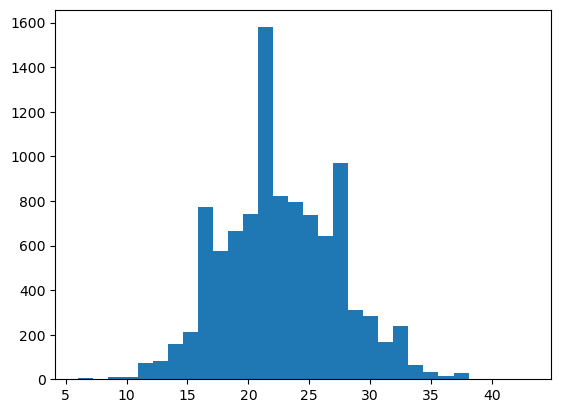

In [3]:
from matplotlib.pyplot import hist
%matplotlib inline

out = [calculate_value(4,2,1000) for _ in range(10000)]
outvec = np.array(out)

plot = hist(outvec, bins=30)


Indeed this is roughly what we should expect.

### Problem 5

Use the transformation method to compute realizations of the probability density function $q(m)=3m^2$ on the interval $(0,1)$, starting from realizations of the uniform
distribution $p(d)=1$. Check your results by plotting a histogram.

#### Solution

We calculate $d = \int q(m) dm = \int 3m^2 dm = m^3 = Q(m)$ We then invert to get $m = \sqrt[3]{d}$


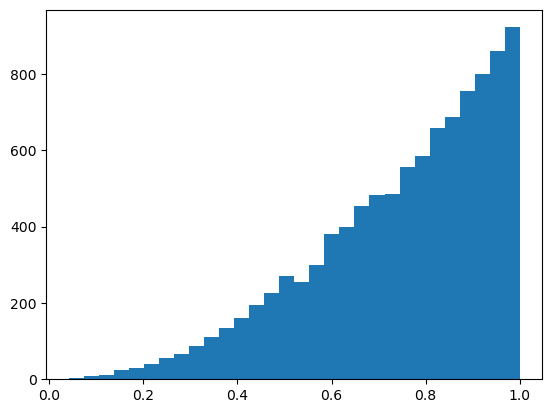

In [4]:
def transform(N):
    d = np.random.uniform(size = N)
    m = np.cbrt(d)
    return m

plot = hist(transform(10000), bins = 30)